In [3]:


# Import the file upload utility from the Google Colab library
from google.colab import files

# Open the file picker to upload the dataset locally from the computer
uploaded = files.upload()



Saving tayseer_services.csv to tayseer_services.csv


In [4]:
import pandas as pd
# load data
df = pd.read_csv('tayseer_services.csv', parse_dates=['month'])
df.dtypes

,0
month,datetime64[ns]
region,object
service_category,object
channel,object
transactions,int64
unique_users,int64
digital_adoption_pct,float64
avg_completion_min,float64
cost_per_txn_sar,float64
csat,float64


In [23]:
# Get the weighted CSAT
def get_customer_satisfaction(df):
    return (df['csat'] * df['unique_users']).sum() / df['unique_users'].sum()


# Total monthly transactions for each channel
transactions = (
    df.groupby(['month', 'channel'])['transactions']
      .sum()
      .reset_index()
)


# Calculate monthly transaction share
transactions['transaction_share'] = (
    transactions['transactions']
    / transactions.groupby('month')['transactions'].transform('sum')
    * 100
)


# Weighted CSAT by channel
channel_csat = (
    df.groupby('channel')
      .apply(get_customer_satisfaction, include_groups=False)
      .reset_index(name='csat')
      .sort_values('csat', ascending=True)
)

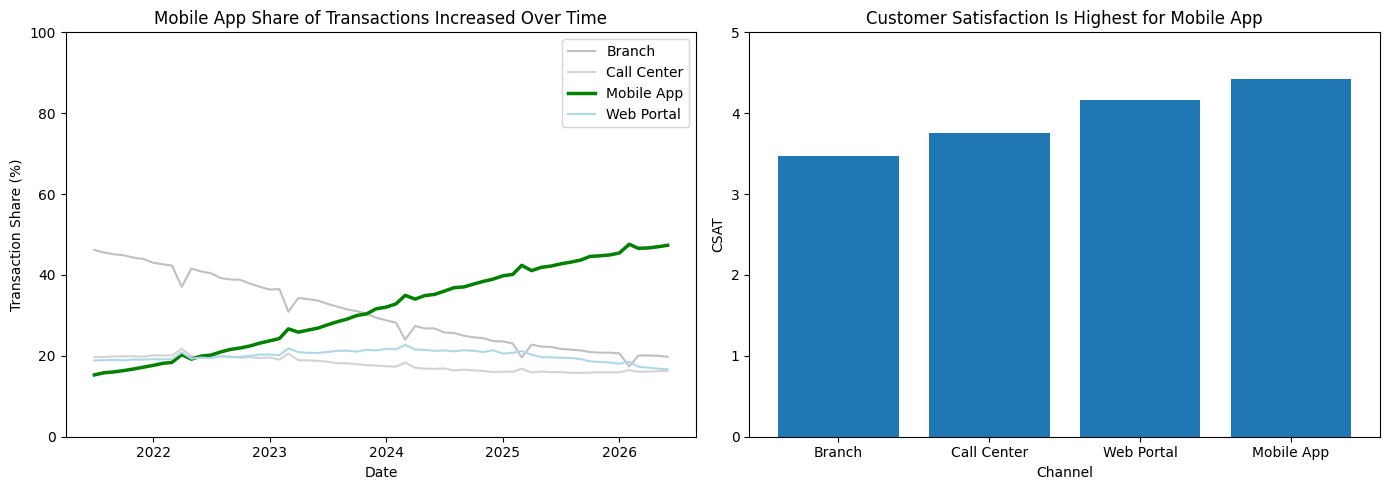

In [24]:
# Create two charts
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Line chart
channel_colors = {
    'Mobile App': 'green',
    'Web Portal': 'lightblue',
    'Call Center': 'lightgray',
    'Branch': 'silver'
}

for channel in transactions['channel'].unique():
    data = transactions[transactions['channel'] == channel]

    if channel == 'Mobile App':
        axes[0].plot(
            data['month'],
            data['transaction_share'],
            label=channel,
            color=channel_colors[channel],
            linewidth=2.5
        )
    else:
        axes[0].plot(
            data['month'],
            data['transaction_share'],
            label=channel,
            color=channel_colors[channel],
            linewidth=1.5
        )

axes[0].set_title('Mobile App Share of Transactions Increased Over Time')
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Transaction Share (%)')
axes[0].set_ylim(0, 100)
axes[0].legend()


# Bar chart
axes[1].bar(
    channel_csat['channel'],
    channel_csat['csat']
)

axes[1].set_title('Customer Satisfaction Is Highest for Mobile App')
axes[1].set_xlabel('Channel')
axes[1].set_ylabel('CSAT')
axes[1].set_ylim(0, 5)

plt.tight_layout()
plt.show()